# FlowMatchingRegistrationPFN: MLflow curves + lower/upper/model comparison

Analysis notebook for `01-pretraining-lupi-flow-matching-registration` (this branch, `lupi-registration-sde`), compared against the peer session's `01-pretraining-lupi-bounds` checkpoint (severed lower / pooled oracle upper). See:
- `docs/labbook/2026-09-17-flow-matching-registration-real-run-launch.md` -- launch, pre-registered hypotheses, epoch-by-epoch log
- `docs/labbook/2026-09-17-bounded01-ported-and-val-batch-bug.md` -- the bounded01 prior + val-batch fix both runs depend on
- `scripts/plot_bounds_vs_flow_matching_registration_1d.py` -- the standalone script this notebook's comparison-plot cell is adapted from

Both MLflow tracking servers must be reachable (tunneled from ulysses): `http://127.0.0.1:5001` (this branch's own `mlruns`) and `http://127.0.0.1:5000` (the peer's `Meta_FTPFN/mlruns`, for the bounds checkpoint). If either isn't up, re-run `scripts/uly_mlflow.sh`-style tunnels first (see the labbook entry for the exact commands used).

In [1]:
from __future__ import annotations

import dataclasses
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from mlflow.tracking import MlflowClient

import sys
sys.path.insert(0, str(Path.cwd().parent / "src"))

from ppfn.model.baselines.lupi_bounds_pfn import BoundsPFN
from ppfn.model.baselines.lupi_flow_matching_pfn import FlowMatchingRegistrationPFN
from ppfn.model.pfn.bar_distribution import FullSupportBarDistribution
from ppfn.prior.lupi.dataset import D_MAX, LUPIBatch, collate_lupi_batch
from ppfn.prior.lupi.sampler import sample_pair

MY_TRACKING_URI = "http://127.0.0.1:5001"   # this branch's own mlruns (Meta_FTPFN-sde)
PEER_TRACKING_URI = "http://127.0.0.1:5000"  # peer session's mlruns (Meta_FTPFN)
EXPERIMENT_NAME = "lupi-decoder-comparison"
MY_RUN_NAME = "flow-matching-registration"   # configs/experiment/lupi_flow_matching_registration.yaml's callbacks.mlflow.run_name
PEER_BOUNDS_RUN_NAME = "no-id-shared-bounds"  # configs/experiment/lupi_bounds.yaml's own run_name

In [2]:
def latest_run(tracking_uri: str, experiment_name: str, run_name_prefix: str, rank_key: str):
    """Picks the run matching `run_name_prefix` whose `rank_key` metric was
    logged MOST RECENTLY (by wall-clock timestamp, not step count or
    start_time) -- the only signal that survives every failure mode found
    while building this cell, in the order found:
      1. start_time DESC alone picked a run that LOOKED stuck (3 logged
         epochs) purely because it was queried early in its own life --
         not actually a distinct failure, just a timing snapshot, but
         motivated looking harder.
      2. "most metric history" then picked a genuinely different, OLD
         FINISHED run (100 epochs, but from BEFORE today's bounded01-prior
         fix) over the correct live one -- a real checkpoint-provenance
         trap, hit via history length instead of a stale .pt file.
      3. "prefer RUNNING, most history among those" (this cell's previous
         version) fixed #2 but breaks on a NEW real scenario: a run
         `kill -9`'d mid-training never calls on_train_end, so it stays
         marked RUNNING FOREVER in MLflow with its history frozen at
         whatever it last logged -- exactly what happened to THIS
         branch's own first attempt (killed at epoch 20 by an unrelated
         peer `pkill`, see docs/labbook/2026-09-17-first-run-killed-
         diagnosis-and-relaunch.md). Its relaunch reuses the SAME run_name
         (a run_name collision, not fixed at the config level), starts
         from 0 logged points, and would lose to the frozen zombie's 21
         points under a "most history" rule for the next ~21 epochs.
    Freshness (max metric timestamp) is the one property that's true of
    "the process that's actually alive right now" and false of both a
    long-dead zombie AND an old finished run, regardless of either's
    history length."""
    client = MlflowClient(tracking_uri=tracking_uri)
    exp = client.get_experiment_by_name(experiment_name)
    if exp is None:
        raise RuntimeError(f"no experiment {experiment_name!r} at {tracking_uri}")
    runs = client.search_runs(
        [exp.experiment_id],
        filter_string=f"tags.mlflow.runName LIKE '{run_name_prefix}%'",
        order_by=["start_time DESC"],
        max_results=20,
    )
    if not runs:
        raise RuntimeError(f"no run matching {run_name_prefix!r} in {experiment_name!r} at {tracking_uri}")
    best_run, best_ts, best_n = None, -1, 0
    for r in runs:
        hist = client.get_metric_history(r.info.run_id, rank_key)
        if not hist:
            continue
        ts = max(h.timestamp for h in hist)
        if ts > best_ts:
            best_run, best_ts, best_n = r, ts, len(hist)
    if best_run is None:
        raise RuntimeError(f"no run matching {run_name_prefix!r} has ANY {rank_key!r} history")
    import datetime
    print(f"{run_name_prefix}: picked {best_run.info.run_id} (status={best_run.info.status}, "
          f"{best_n} points, last logged {datetime.datetime.fromtimestamp(best_ts/1000)})")
    return client, best_run

def metric_history_df(client: MlflowClient, run_id: str, keys: list[str]) -> pd.DataFrame:
    frames = {}
    for k in keys:
        hist = client.get_metric_history(run_id, k)
        if hist:
            frames[k] = pd.Series({h.step: h.value for h in hist})
    return pd.DataFrame(frames).sort_index()

my_client, my_run = latest_run(MY_TRACKING_URI, EXPERIMENT_NAME, MY_RUN_NAME, rank_key="loss/nll_teacher")
peer_client, peer_run = latest_run(PEER_TRACKING_URI, EXPERIMENT_NAME, PEER_BOUNDS_RUN_NAME, rank_key="loss/upper_nll")
print("my run:", my_run.info.run_id, my_run.info.status)
print("peer bounds run:", peer_run.info.run_id, peer_run.info.status)

flow-matching-registration: picked 641d057ff18f4051b27507c32bdfb6dd (status=RUNNING, 59 points, last logged 2026-09-18 05:25:03.448000)


no-id-shared-bounds: picked 6678b019baa049cea63b64460a613e55 (status=RUNNING, 27 points, last logged 2026-09-18 05:18:26.082000)
my run: 641d057ff18f4051b27507c32bdfb6dd RUNNING
peer bounds run: 6678b019baa049cea63b64460a613e55 RUNNING


In [3]:
my_keys = ["loss/nll_student", "loss/nll_teacher", "loss/upper1_gap", "flow/total", "loss/ce_distil",
           "val/loss/nll_student", "val/loss/nll_teacher", "val/loss/upper1_gap", "val/flow/total"]
my_df = metric_history_df(my_client, my_run.info.run_id, my_keys)

peer_keys = ["loss/lower_nll", "loss/upper_nll", "loss/bounds_gap",
             "val/loss/lower_nll", "val/loss/upper_nll", "val/loss/bounds_gap"]
peer_df = metric_history_df(peer_client, peer_run.info.run_id, peer_keys)

print(f"my run: {len(my_df)} logged steps, up to step {my_df.index.max()}")
print(f"peer bounds run: {len(peer_df)} logged steps, up to step {peer_df.index.max()}")
my_df.tail()

my run: 59 logged steps, up to step 58
peer bounds run: 27 logged steps, up to step 26


,loss/nll_student,loss/nll_teacher,loss/upper1_gap,flow/total,loss/ce_distil,val/loss/nll_student,val/loss/nll_teacher,val/loss/upper1_gap,val/flow/total
54,-1.740800,-2.080127,0.339326,0.002717,2.433364,-1.763281,-2.175864,0.412582,0.006350
55,-1.581137,-1.956568,0.375430,0.003141,2.409540,-1.845934,-2.207505,0.361570,0.006380
56,-1.804028,-2.132895,0.328866,0.002264,2.335853,-1.766895,-2.187910,0.421014,0.006457
57,-1.947132,-2.189514,0.242382,0.002240,2.264389,-1.724080,-2.231043,0.506963,0.005934
58,-1.688245,-2.151424,0.463179,0.005344,2.433053,-1.858562,-2.247798,0.389236,0.005887


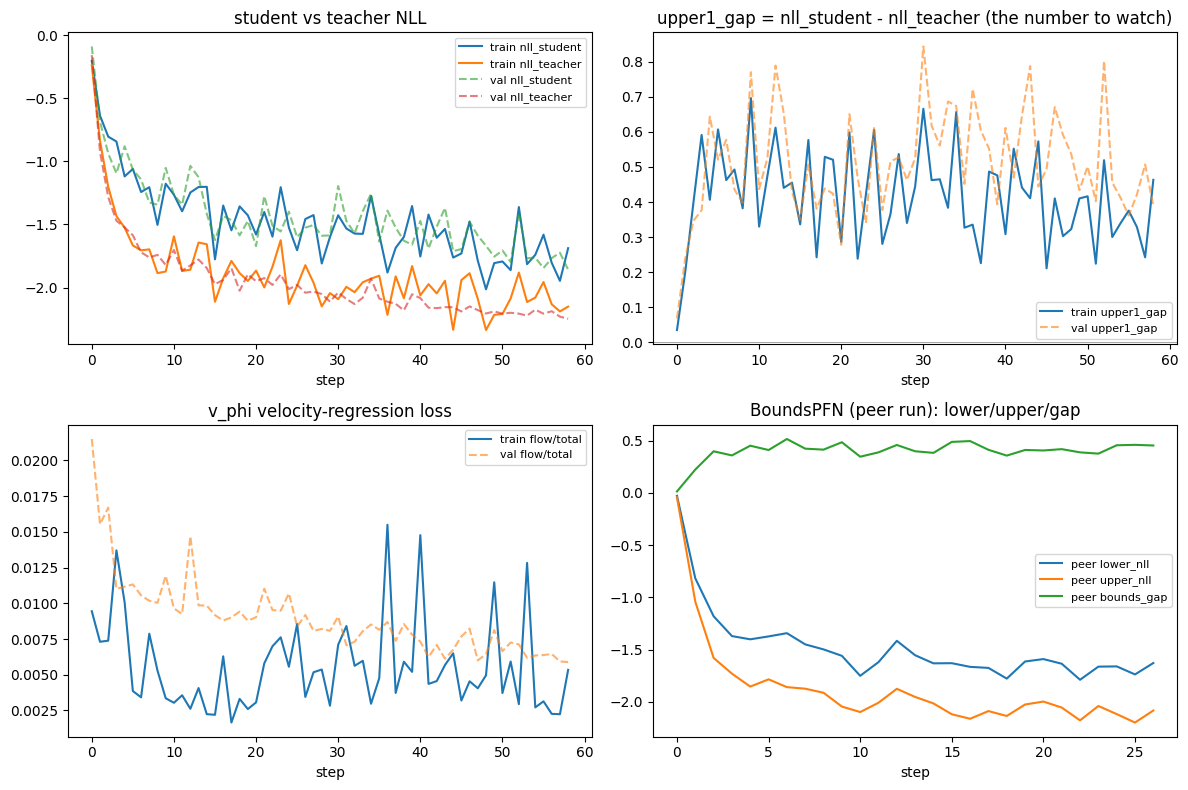

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.plot(my_df.index, my_df["loss/nll_student"], label="train nll_student")
ax.plot(my_df.index, my_df["loss/nll_teacher"], label="train nll_teacher")
ax.plot(my_df.index, my_df["val/loss/nll_student"], "--", label="val nll_student", alpha=0.6)
ax.plot(my_df.index, my_df["val/loss/nll_teacher"], "--", label="val nll_teacher", alpha=0.6)
ax.set_title("student vs teacher NLL"); ax.set_xlabel("step"); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(my_df.index, my_df["loss/upper1_gap"], label="train upper1_gap")
ax.plot(my_df.index, my_df["val/loss/upper1_gap"], "--", label="val upper1_gap", alpha=0.6)
ax.axhline(0, color="gray", lw=0.5)
ax.set_title("upper1_gap = nll_student - nll_teacher (the number to watch)"); ax.set_xlabel("step"); ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(my_df.index, my_df["flow/total"], label="train flow/total")
ax.plot(my_df.index, my_df["val/flow/total"], "--", label="val flow/total", alpha=0.6)
ax.set_title("v_phi velocity-regression loss"); ax.set_xlabel("step"); ax.legend(fontsize=8)

ax = axes[1, 1]
if len(peer_df):
    ax.plot(peer_df.index, peer_df["loss/lower_nll"], label="peer lower_nll")
    ax.plot(peer_df.index, peer_df["loss/upper_nll"], label="peer upper_nll")
    ax.plot(peer_df.index, peer_df["loss/bounds_gap"], label="peer bounds_gap")
ax.set_title("BoundsPFN (peer run): lower/upper/gap"); ax.set_xlabel("step"); ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig("flow_matching_registration_training_curves.png", dpi=150)
plt.show()

## Fetch the latest checkpoints from ulysses

Cached under `notebooks/_checkpoint_cache/` (gitignored -- these are large binary artifacts, not repo content).

In [5]:
CACHE_DIR = Path("_checkpoint_cache")
CACHE_DIR.mkdir(exist_ok=True)

MY_CKPT_REMOTE = "ulysses:~/PycharmProjects/Meta_FTPFN-sde/models/01-pretraining-lupi-flow-matching-registration/best_01-pretraining-lupi-flow-matching-registration.pt"
PEER_CKPT_REMOTE = "ulysses:~/PycharmProjects/Meta_FTPFN/models/01-pretraining-lupi-bounds/best_01-pretraining-lupi-bounds.pt"

my_ckpt_path = CACHE_DIR / "best_flow_matching_registration.pt"
peer_ckpt_path = CACHE_DIR / "best_lupi_bounds.pt"
subprocess.run(["scp", "-q", MY_CKPT_REMOTE, str(my_ckpt_path)], check=True)
subprocess.run(["scp", "-q", PEER_CKPT_REMOTE, str(peer_ckpt_path)], check=True)
print("fetched:", my_ckpt_path, my_ckpt_path.stat().st_size, "bytes")
print("fetched:", peer_ckpt_path, peer_ckpt_path.stat().st_size, "bytes")

fetched: _checkpoint_cache/best_flow_matching_registration.pt 77287782 bytes
fetched: _checkpoint_cache/best_lupi_bounds.pt 38330902 bytes


In [6]:
BOUNDS_KW = dict(d_max=D_MAX, d_model=256, n_heads=8, n_layers=6, d_ff=512, n_bins_predictive=64, bounded01=True)
REGISTRATION_KW = dict(
    d_max=D_MAX, d_model=256, n_heads=8, n_layers=6, d_ff=512, n_bins_predictive=64,
    fm_d_model=256, fm_n_heads=8, fm_n_layers=6, fm_d_ff=512,
    n_transport_samples=1, sde_sigma=0.0, n_integration_steps=10, bounded01=True,
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"{ckpt_path.name}: epoch={ckpt.get('epoch')} best_score={ckpt.get('best_score')}")
    return model.to(device).eval()

bounds_model = load_model(BoundsPFN(**BOUNDS_KW), peer_ckpt_path)
registration_model = load_model(FlowMatchingRegistrationPFN(**REGISTRATION_KW), my_ckpt_path)

best_lupi_bounds.pt: epoch=22 best_score=-1.9889627695083618
best_flow_matching_registration.pt: epoch=58 best_score=-1.8585615158081055


/home/ruhkopf/PycharmProjects/Meta_FTPFN/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


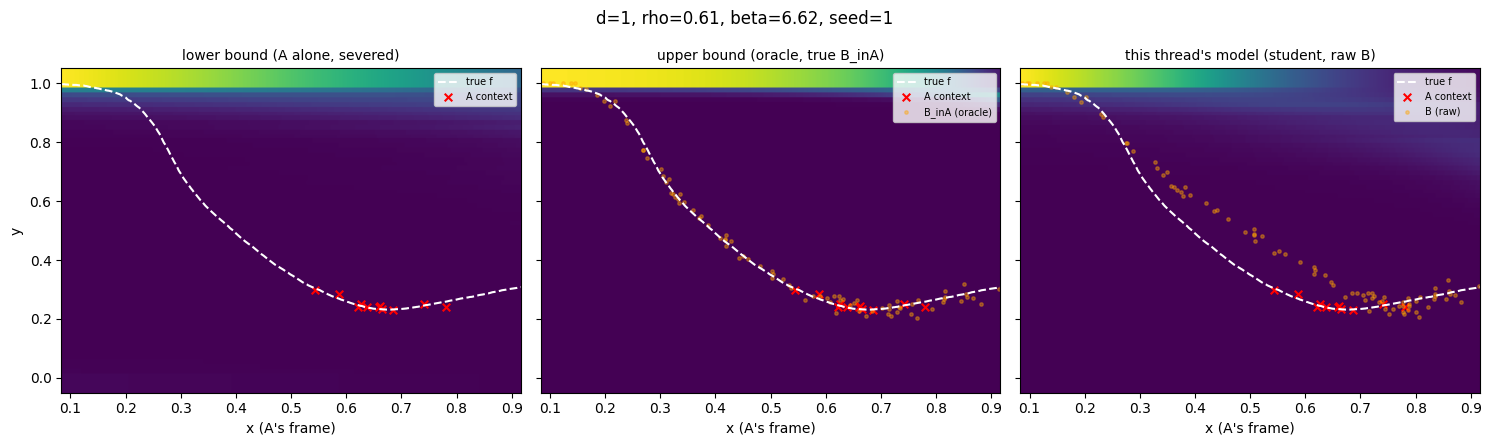

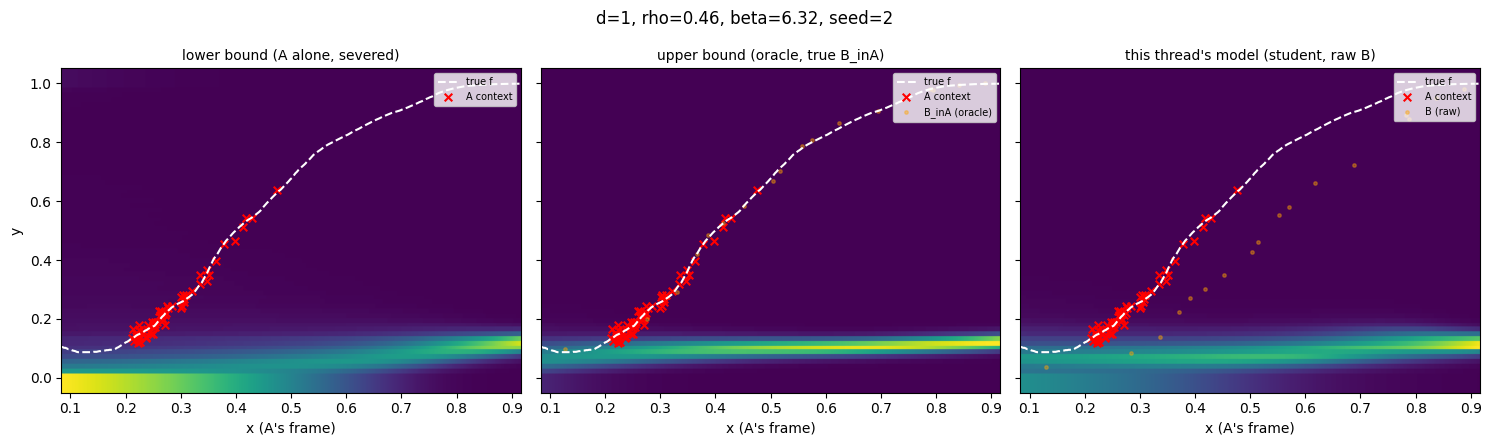

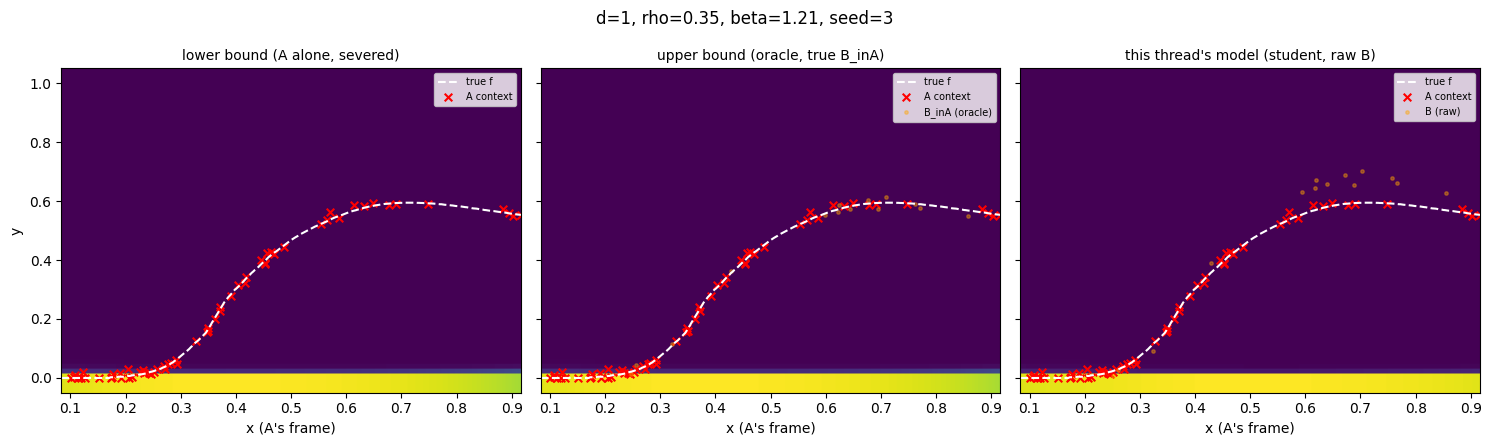

In [7]:
def build_grid_batch(batch, x_grid):
    n_grid = x_grid.shape[0]
    grid_x = torch.zeros(1, n_grid, D_MAX, dtype=torch.float32, device=device)
    grid_x[0, :, 0] = torch.from_numpy(x_grid.astype(np.float32))
    grid_mask = torch.ones(1, n_grid, dtype=torch.bool, device=device)
    return dataclasses.replace(batch, dec_qry_x=grid_x, dec_qry_mask=grid_mask)

def heatmap(ax, bar_dist, x_grid, logits, y_lo, y_hi, n_y=200):
    y_vals = torch.linspace(y_lo, y_hi, n_y)
    idx = bar_dist.map_to_bucket_idx(y_vals.unsqueeze(0).expand(logits.shape[0], -1))
    scaled_log_probs = bar_dist.compute_scaled_log_probs(logits)
    density = scaled_log_probs.gather(-1, idx).exp()
    ax.imshow(density.T.numpy(), origin="lower", aspect="auto", cmap="viridis",
              extent=[x_grid.min(), x_grid.max(), y_lo, y_hi])

def make_comparison_plot(seed: int):
    rng = np.random.default_rng(seed)
    pair, internals = sample_pair(
        rng, rho=float(rng.uniform(0.3, 0.9)), d=1, n_a_range=(8, 100), n_b_range=(8, 100),
        n_qry_range=(8, 64), warp_grid_n=4, bounded01=True, return_internals=True,
    )
    item = {
        "d_real": pair.d, "rho": np.float32(pair.rho), "beta": np.float32(pair.beta),
        "enc_x": pair.x_b.astype(np.float32), "enc_z": pair.z_b.astype(np.float32),
        "enc_x_inA": pair.x_b_inA.astype(np.float32), "enc_z_inA": pair.z_b_inA.astype(np.float32),
        "dec_ctx_x": pair.x_a_ctx.astype(np.float32), "dec_ctx_z": pair.z_a_ctx.astype(np.float32),
        "dec_ctx_oracle_bpos": pair.oracle_bpos_a_ctx.astype(np.float32),
        "dec_qry_x": pair.x_a_qry.astype(np.float32), "dec_qry_z": pair.z_a_qry.astype(np.float32),
        "dec_qry_oracle_bpos": pair.oracle_bpos_a_qry.astype(np.float32),
        "dec_qry_source": pair.qry_source,
        "region_type": pair.meta["region_type"], "volume_fraction": pair.meta["volume_fraction"],
    }
    batch = collate_lupi_batch([item])
    batch = dataclasses.replace(batch, **{
        f.name: (getattr(batch, f.name).to(device) if isinstance(getattr(batch, f.name), torch.Tensor) else getattr(batch, f.name))
        for f in dataclasses.fields(batch)
    })

    z_grid = np.linspace(0.0, 1.0, 300).reshape(-1, 1)
    x_grid = internals.to_a(z_grid)[:, 0]
    order = np.argsort(x_grid)
    x_grid, z_grid = x_grid[order], z_grid[order]
    true_y = internals.true_value_as_a(z_grid)
    grid_batch = build_grid_batch(batch, x_grid)

    with torch.no_grad():
        lower_logits = bounds_model(grid_batch, severed=True)["predictive_logits"][0].cpu()
        upper_logits = bounds_model(grid_batch, severed=False)["predictive_logits"][0].cpu()
        model_logits = registration_model(grid_batch)["student_logits"][0].cpu()

    y_lo, y_hi = -0.05, 1.05
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    panels = [
        (axes[0], "lower bound (A alone, severed)", bounds_model.bar_dist, lower_logits, None),
        (axes[1], "upper bound (oracle, true B_inA)", bounds_model.bar_dist, upper_logits,
         (pair.x_b_inA[:, 0], pair.z_b_inA, "B_inA (oracle)")),
        (axes[2], "this thread's model (student, raw B)", registration_model.bar_dist, model_logits,
         (pair.x_b[:, 0], pair.z_b, "B (raw)")),
    ]
    for ax, title, bar_dist, logits, b_scatter in panels:
        heatmap(ax, bar_dist, x_grid, logits, y_lo, y_hi)
        ax.plot(x_grid, true_y, color="white", lw=1.5, ls="--", label="true f")
        ax.scatter(pair.x_a_ctx[:, 0], pair.z_a_ctx, s=30, color="red", marker="x", label="A context")
        if b_scatter is not None:
            bx, bz, blabel = b_scatter
            ax.scatter(bx, bz, s=6, alpha=0.4, color="orange", label=blabel)
        ax.set_title(title, fontsize=10); ax.set_xlabel("x (A's frame)"); ax.legend(fontsize=7, loc="upper right")
    axes[0].set_ylabel("y")
    fig.suptitle(f"d=1, rho={pair.rho:.2f}, beta={pair.beta:.2f}, seed={seed}")
    fig.tight_layout()
    return fig

for seed in (1, 2, 3):
    fig = make_comparison_plot(seed)
    fig.savefig(f"comparison_seed{seed}.png", dpi=150)
    plt.show()

## Findings (as of 2026-09-18 ~05:30, epoch 58/100, run still in progress)

Full writeup: `docs/labbook/2026-09-18-overnight-run-checkin-curriculum-fix-insufficient.md`.

- **`upper1_gap` (`nll_student - nll_teacher`) plateaus around 0.35-0.4 mean
  from epoch 20 onward and has NOT closed**, despite the student-weight/
  CE-temperature curriculum fix working exactly as intended (`ce_distil`
  genuinely declining, `flow/total` low and controlled). The fix solved
  the problem it targeted (CE dominance) without solving the actual
  research question (closing the registration gap) -- these turned out to
  be different problems.
- **The peer's `BoundsPFN` run shows a same-magnitude `bounds_gap≈0.39`**
  with no explicit registration mechanism at all -- a useful cross-check
  that at least part of this ~0.4 may be how hard the task/prior currently
  is at this point in training, not a defect specific to the flow-matching
  mechanism.
- **The 3-column comparison plot is genuinely informative and seed-
  dependent**: on a strongly acquisition-biased draw (seed 1, `beta=6.62`),
  the student panel tracks the true curve about as tightly as the oracle
  panel and is clearly sharper than the severed lower bound. On another
  biased draw (seed 2), even the ORACLE panel fails to extrapolate well
  into a sparsely-covered region -- a shared checkpoint-maturity limitation,
  not something specific to the student pathway. On a weakly-biased draw
  (seed 3, `beta=1.21`), all three panels look equally good, because A
  alone already covers the domain -- exactly the case where registration
  should barely matter, and it doesn't.
- **Revised diagnosis**: the deterministic `K=1`/`sigma=0` transport
  (deliberately the simplest first cut) is now the more likely remaining
  ceiling, not the loss weighting. Not yet tested -- enabling the
  stochastic SDE (`K>1`, `sigma>0`) is a real design decision (multiplies
  per-step compute by `K`, is the original hypothesis this whole branch
  exists to test) flagged for a second opinion rather than done
  autonomously.